# Forecasting 0 & 2

This notebook is organized by cluster and by model:

1. Cluster 0: model 1 (`c0_m1`) and model 2 (`c0_m2`)
2. Cluster 2: model 1 (`c2_m1`) and model 2 (`c2_m2`)

Each section includes:
- config
- run
- evaluation
- aggregate plot
- top-SKU plots


In [ ]:
import ast
import importlib
import json
import textwrap
import warnings
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import c0_m1
import c0_m2
import c0c2_analysis
import c1c3_analysis
import c2_m1
import c2_m2

importlib.reload(c0_m1)
importlib.reload(c0_m2)
importlib.reload(c0c2_analysis)
importlib.reload(c1c3_analysis)
importlib.reload(c2_m1)
importlib.reload(c2_m2)

In [ ]:
from c0_m1 import (
    DISPLAY_NAME as C0_M1_DISPLAY_NAME,
    PRED_COL as C0_M1_PRED_COL,
    default_param_space as c0_m1_default_param_space,
    forecast_panel as c0_m1_forecast_panel,
    load_data as c0_m1_load_data,
    tune_hyperparams_random_search as c0_m1_tune,
)
from c0_m2 import (
    DISPLAY_NAME as C0_M2_DISPLAY_NAME,
    PRED_COL as C0_M2_PRED_COL,
    run_c0_m2_pipeline,
)
from c0c2_analysis import build_analysis_artifact, build_pair_prediction_frame, build_single_prediction_frame
from c1c3_analysis import build_cluster_metric_tables, run_cluster_analysis
from c2_m1 import (
    DISPLAY_NAME as C2_M1_DISPLAY_NAME,
    PRED_COL as C2_M1_PRED_COL,
    default_param_space as c2_m1_default_param_space,
    forecast_panel as c2_m1_forecast_panel,
    load_data as c2_m1_load_data,
    tune_hyperparams_random_search as c2_m1_tune,
)
from c2_m2 import (
    DEFAULT_CATEGORICAL_FEATURE_COLS as C2_DEFAULT_CATEGORICAL_FEATURE_COLS,
    DEFAULT_FEATURE_COLS as C2_DEFAULT_FEATURE_COLS,
    DISPLAY_NAME as C2_M2_DISPLAY_NAME,
    PRED_COL as C2_M2_PRED_COL,
    run_c2_m2_pipeline,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)


def load_notebook_functions(notebook_path, function_names, global_ns=None):
    notebook = json.loads(Path(notebook_path).read_text())
    global_ns = {} if global_ns is None else dict(global_ns)
    loaded = {}
    targets = set(function_names)

    for cell in notebook['cells']:
        if cell.get('cell_type') != 'code':
            continue
        source = ''.join(cell.get('source', []))
        if not source.strip():
            continue
        try:
            module = ast.parse(source)
        except SyntaxError:
            continue
        for node in module.body:
            if isinstance(node, ast.FunctionDef) and node.name in targets and node.name not in loaded:
                fn_src = textwrap.dedent(ast.get_source_segment(source, node))
                exec(fn_src, global_ns)
                loaded[node.name] = global_ns[node.name]
    missing = targets.difference(loaded)
    if missing:
        raise ValueError(f'Missing notebook functions: {sorted(missing)}')
    return loaded

c1c3_nb_fns = load_notebook_functions(
    'c1c3forecasting.ipynb',
    function_names=['plot_random_skus_train_test'],
    global_ns={'pd': pd, 'np': np, 'plt': plt, 'SimpleNamespace': SimpleNamespace},
)
c1c3_plot_random_skus_train_test = c1c3_nb_fns['plot_random_skus_train_test']


In [426]:
def display_metric_table(metric_table, title=None):
    if title:
        print(title)
    display(metric_table)


def evaluate_single_model(actual_df, pred_df, pred_col, method_label, eps=1.0):
    pred_long = build_single_prediction_frame(
        sku_actual_df=actual_df,
        sku_pred_df=pred_df,
        pred_col=pred_col,
    )
    return build_cluster_metric_tables(
        pred_df=pred_long,
        method_cols={method_label: pred_col},
        eps=eps,
    )


def run_pair_analysis(
    actual_df,
    baseline_df,
    model_df,
    train_feat,
    test_feat,
    cluster_id,
    cluster_tag,
    baseline_label,
    model_label,
    baseline_col,
    model_col,
    eps=1.0,
    n_periods=4,
):
    pred_df = build_pair_prediction_frame(
        sku_actual_df=actual_df,
        baseline_pred_df=baseline_df,
        model_pred_df=model_df,
        baseline_col=baseline_col,
        model_col=model_col,
        cluster_id=cluster_id,
    )
    art = build_analysis_artifact(
        train_feat=train_feat,
        test_feat=test_feat,
        pred_df=pred_df,
    )
    analysis = run_cluster_analysis(
        art=art,
        cluster_tag=cluster_tag,
        baseline_col=baseline_col,
        model_col=model_col,
        eps=eps,
        n_periods=n_periods,
    )
    metric_table = analysis['metric_table'].copy()
    metric_table['method'] = metric_table['method'].map({
        'baseline': baseline_label,
        'model': model_label,
    }).fillna(metric_table['method'])
    analysis['metric_table'] = metric_table
    analysis['pred_df'] = pred_df
    return analysis


def plot_top_sku_comparison(
    train_df,
    actual_df,
    baseline_df,
    model_df,
    top_n=6,
    title_prefix='Cluster',
    baseline_col='baseline_pred',
    model_col='model_pred',
    random_state=123,
):
    pred_df = build_pair_prediction_frame(
        sku_actual_df=actual_df,
        baseline_pred_df=baseline_df,
        model_pred_df=model_df,
        baseline_col=baseline_col,
        model_col=model_col,
    )
    top_skus = (
        actual_df.sum(axis=0)
        .sort_values(ascending=False)
        .head(top_n)
        .index.tolist()
    )
    train_panel = train_df[train_df['product_family_name'].isin(top_skus)].copy()
    pred_panel = pred_df[pred_df['product_family_name'].isin(top_skus)].copy()
    art = SimpleNamespace(train_panel=train_panel, pred_df=pred_panel)
    c1c3_plot_random_skus_train_test(
        art=art,
        cluster_label=title_prefix,
        baseline_col=baseline_col,
        model_col=model_col,
        n_skus=len(top_skus),
        random_state=random_state,
    )


## Cluster 0

In [427]:
# Cluster 0 config
cluster0_id = 0
cluster0_eps_mape = 1.0
cluster0_metric_name = 'bounded_mape'
cluster0_n_periods = 4
cluster0_random_state = 42
cluster0_random_search_mode = 'fast'
cluster0_random_search_iter = 8
cluster0_val_days = 28
cluster0_plot_top_n_skus = 6


In [428]:
# Cluster 0 shared data
cluster0_train_df, cluster0_test_df = c0_m1_load_data(cluster_id=cluster0_id)

print('cluster0 train shape:', cluster0_train_df.shape)
print('cluster0 test shape:', cluster0_test_df.shape)
print('cluster0 train sku:', cluster0_train_df['product_family_name'].nunique())
print('cluster0 test sku:', cluster0_test_df['product_family_name'].nunique())


cluster0 train shape: (132021, 4)
cluster0 test shape: (41768, 4)
cluster0 train sku: 515
cluster0 test sku: 491


In [429]:
# Cluster 0 - Model 1 (`c0_m1`) run
cluster0_model1_param_space = c0_m1_default_param_space(
    eps=cluster0_eps_mape,
    mode=cluster0_random_search_mode,
)

cluster0_model1_best_params, cluster0_model1_tuning_df = c0_m1_tune(
    train_df=cluster0_train_df,
    param_space=cluster0_model1_param_space,
    val_days=cluster0_val_days,
    n_iter=cluster0_random_search_iter,
    random_state=cluster0_random_state,
    verbose=True,
)

cluster0_model1_actual_df, cluster0_model1_pred_df, cluster0_model1_info_df = c0_m1_forecast_panel(
    train_df=cluster0_train_df,
    test_df=cluster0_test_df,
    params=cluster0_model1_best_params,
)

print('Cluster 0 Model 1 best params:')
print(cluster0_model1_best_params)
display(cluster0_model1_tuning_df.head(20))
display(cluster0_model1_info_df.head(20))


[1/8] score=124.1413 cap_mape=71.1560 zero_fpr=0.7641 overshoot=73.9032
[2/8] score=116.5405 cap_mape=67.1956 zero_fpr=0.6865 overshoot=75.1030
[3/8] score=138.1517 cap_mape=79.5350 zero_fpr=0.9219 overshoot=62.6060
[4/8] score=122.5624 cap_mape=70.2029 zero_fpr=0.7438 overshoot=75.8415
[5/8] score=112.8436 cap_mape=64.2149 zero_fpr=0.6311 overshoot=85.3730
[6/8] score=122.0520 cap_mape=70.2381 zero_fpr=0.7405 overshoot=73.9344
[7/8] score=129.8755 cap_mape=75.1074 zero_fpr=0.8449 overshoot=62.6198
[8/8] score=125.7798 cap_mape=72.9073 zero_fpr=0.7923 overshoot=66.2932
Cluster 0 Model 1 best params:
{'min_train_len': 28, 'min_nonzero_count': 6, 'min_nonzero_ratio': 0.05, 'wmape_eps': 1.0, 'sale_threshold': 2.0, 'pred_positive_threshold': 0.5, 'lambda_zero_fp': 50.0, 'lambda_zero_overshoot': 0.2, 'zero_scale_quantile': 50.0, 'cap_quantile': 95.0, 'cap_multiplier': 1.25, 'cap_lookback': 84, 'fallback_lookback_days': 56, 'fallback_global_window': 28, 'fallback_shrink': 0.7, 'fallback_cap_

,min_train_len,min_nonzero_count,min_nonzero_ratio,wmape_eps,sale_threshold,pred_positive_threshold,lambda_zero_fp,lambda_zero_overshoot,zero_scale_quantile,cap_quantile,cap_multiplier,cap_lookback,fallback_lookback_days,fallback_global_window,fallback_shrink,fallback_cap_quantile,fallback_cap_multiplier,fallback_cap_lookback,alpha_d,alpha_p,search_score,metric_mape,metric_epsilon_mape,metric_cap_mape,metric_wmape,metric_zero_day_fpr,zero_day_overshoot_pct
0,28,6,0.05,1.0,2.0,0.5,50.0,0.2,50.0,95.0,1.25,84,56,28,0.7,90.0,1.5,56,0.15,0.20,112.843559,64.214913,602.232025,64.214913,105.733105,0.631081,85.372957
1,28,6,0.05,1.0,2.0,0.5,50.0,0.2,50.0,90.0,1.25,84,56,28,0.7,90.0,1.5,56,0.15,0.10,116.540503,67.195580,575.425539,67.195580,104.101229,0.686486,75.102994
2,28,6,0.05,1.0,1.0,0.5,50.0,0.2,50.0,95.0,1.25,84,56,28,0.7,90.0,1.5,56,0.15,0.20,122.052013,70.238107,610.779913,70.238107,106.083822,0.740541,73.934392
3,28,6,0.05,1.0,2.0,0.5,50.0,0.2,50.0,90.0,1.50,84,56,28,0.7,90.0,1.5,56,0.15,0.05,122.562364,70.202946,626.881670,70.202946,106.484543,0.743822,75.841490
4,28,6,0.05,1.0,2.0,0.5,50.0,0.2,50.0,95.0,1.25,84,56,28,0.7,90.0,1.5,56,0.10,0.05,124.141304,71.156021,626.779762,71.156021,105.838124,0.764093,73.903248
5,28,6,0.05,1.0,1.0,0.5,50.0,0.2,50.0,95.0,1.25,84,56,28,0.7,90.0,1.5,56,0.10,0.15,125.779795,72.907258,585.084344,72.907258,104.016773,0.792278,66.293186
6,28,6,0.05,1.0,0.5,0.5,50.0,0.2,50.0,90.0,1.50,84,56,28,0.7,90.0,1.5,56,0.15,0.15,129.875550,75.107389,589.411495,75.107389,104.804632,0.844884,62.619759
7,28,6,0.05,1.0,0.5,0.5,50.0,0.2,50.0,90.0,1.25,84,56,28,0.7,90.0,1.5,56,0.30,0.05,138.151721,79.534953,640.048326,79.534953,108.551940,0.921911,62.606041


,sku,model_type,train_len,nonzero_count,nonzero_ratio
379,SAVOY ART DECO CLOCK,tsb,555,95,0.171171
48,CAKE STAND VICTORIAN FILIGREE LARGE,tsb,555,100,0.180180
35,BLUE PADDED SOFT MOBILE,tsb,555,104,0.187387
186,GLITTERGARLAND,tsb,555,108,0.194595
179,GLASS CAKE COVER AND PLATE,tsb,555,110,0.198198
444,TOOL BOX SOFT TOY,tsb,555,113,0.203604
425,TEAFORONE,tsb,555,114,0.205405
97,COOKING SET RETROSPOT,tsb,555,116,0.209009
212,HEARTT-LIGHTHOLDER,tsb,555,116,0.209009
99,CREAM SWEETHEART MAGAZINE RACK,tsb,555,117,0.210811


In [430]:
# Cluster 0 - Model 1 (`c0_m1`) eval
cluster0_model1_metric_table = evaluate_single_model(
    actual_df=cluster0_model1_actual_df,
    pred_df=cluster0_model1_pred_df,
    pred_col=C0_M1_PRED_COL,
    method_label=f'Cluster 0 / {C0_M1_DISPLAY_NAME}',
    eps=cluster0_eps_mape,
)

display_metric_table(cluster0_model1_metric_table, title='Cluster 0 Model 1 evaluation')


Cluster 0 Model 1 evaluation


,method,wmape_pct,epsilon_mape_pct,cap_mape_0_100,tail_ape_p90,tail_ape_p95,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap,signed_pct_error_mean,signed_abs_bias_ratio
0,Cluster 0 / TSB,113.36437,672.387858,67.456974,1524.180544,2547.707928,0.765049,0.432055,0.332994,636.17539,-0.136379


In [431]:
# Cluster 0 - Model 2 (`c0_m2`) run
cluster0_model2_artifacts = run_c0_m2_pipeline(
    cluster_id=cluster0_id,
    tune=True,
    eps_mape=cluster0_eps_mape,
    random_state=cluster0_random_state,
)

cluster0_model2_actual_df = cluster0_model2_artifacts.sku_actual_df
cluster0_model2_pred_df = cluster0_model2_artifacts.sku_pred_df

print('Cluster 0 Model 2 best config:')
print(cluster0_model2_artifacts.tuning_best_config)
display(cluster0_model2_artifacts.tuning_trials.head(20) if cluster0_model2_artifacts.tuning_trials is not None else None)


Cluster 0 Model 2 best config:
{'cls_params': {'n_estimators': 250, 'learning_rate': 0.03, 'num_leaves': 31, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'class_weight': 'balanced'}, 'reg_params': {'n_estimators': 450, 'learning_rate': 0.03, 'num_leaves': 63, 'min_child_samples': 50, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0, 'random_state': 42}, 'tau': 0.25, 'alpha': 0.9, 'cap_q': 0.98, 'cap_value': 299.8459999999992, 'lambda_zero_fp': 25.0, 'lambda_zero_overshoot': 0.05}


,score,metric_mape,metric_epsilon_mape,metric_wmape,metric_zero_day_fpr,zero_day_overshoot_pct,cls_params,reg_params,tau,alpha,cap_q,cap_value,lambda_zero_fp,lambda_zero_overshoot
0,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.35,0.9,0.98,299.846,25.0,0.05
1,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.25,0.9,0.98,299.846,25.0,0.20
2,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.25,0.9,0.98,299.846,50.0,0.05
3,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.25,0.9,0.98,299.846,50.0,0.10
4,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.35,0.9,0.98,299.846,25.0,0.10
5,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.25,0.9,0.98,299.846,50.0,0.20
6,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.25,0.9,0.98,299.846,75.0,0.05
7,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.25,0.9,0.98,299.846,75.0,0.10
8,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.25,0.9,0.98,299.846,75.0,0.20
9,69.954889,24.748102,56.215845,69.954889,0.0,0.0,"{'n_estimators': 250, 'learning_rate': 0.03, '...","{'n_estimators': 450, 'learning_rate': 0.03, '...",0.35,0.9,0.98,299.846,75.0,0.20


In [432]:
# Cluster 0 - Model 2 (`c0_m2`) eval
cluster0_model2_metric_table = evaluate_single_model(
    actual_df=cluster0_model2_actual_df,
    pred_df=cluster0_model2_pred_df,
    pred_col=C0_M2_PRED_COL,
    method_label=f'Cluster 0 / {C0_M2_DISPLAY_NAME}',
    eps=cluster0_eps_mape,
)

display_metric_table(cluster0_model2_metric_table, title='Cluster 0 Model 2 evaluation')


Cluster 0 Model 2 evaluation


,method,wmape_pct,epsilon_mape_pct,cap_mape_0_100,tail_ape_p90,tail_ape_p95,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap,signed_pct_error_mean,signed_abs_bias_ratio
0,Cluster 0 / Two-stage LGBM,69.84841,62.948834,26.484377,138.090181,312.129628,0.432674,0.432055,0.000619,43.760733,-0.374442


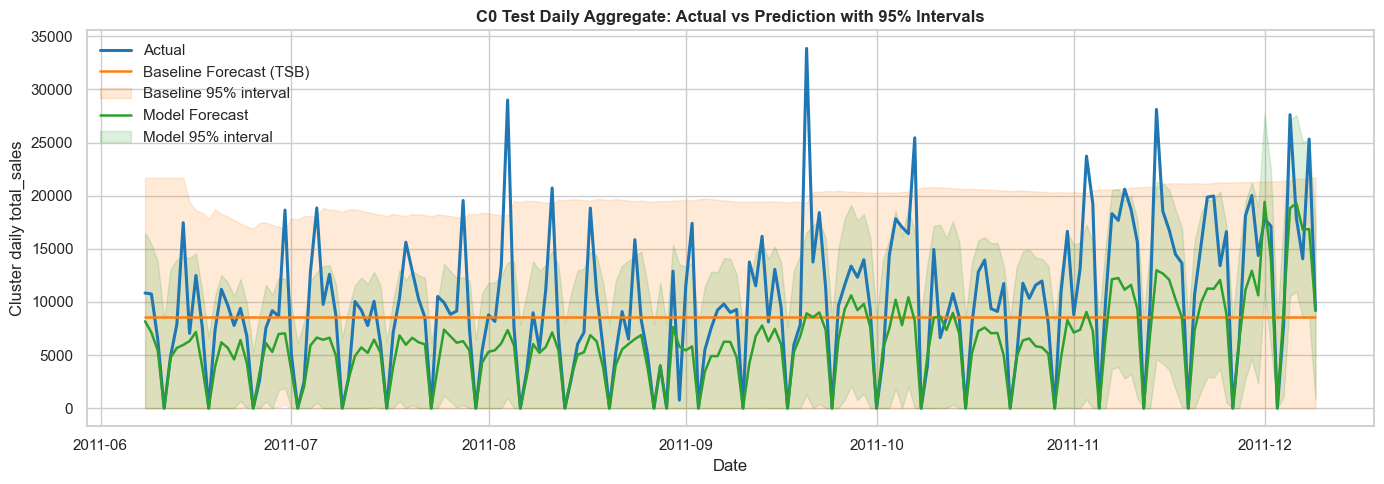

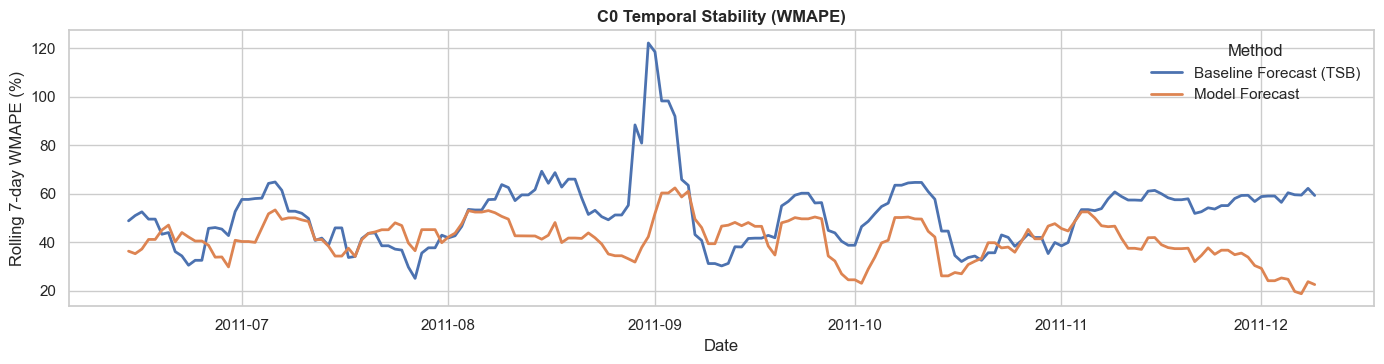

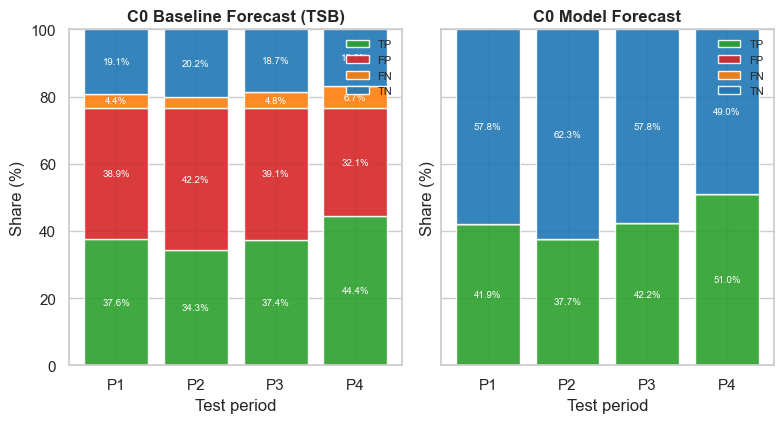

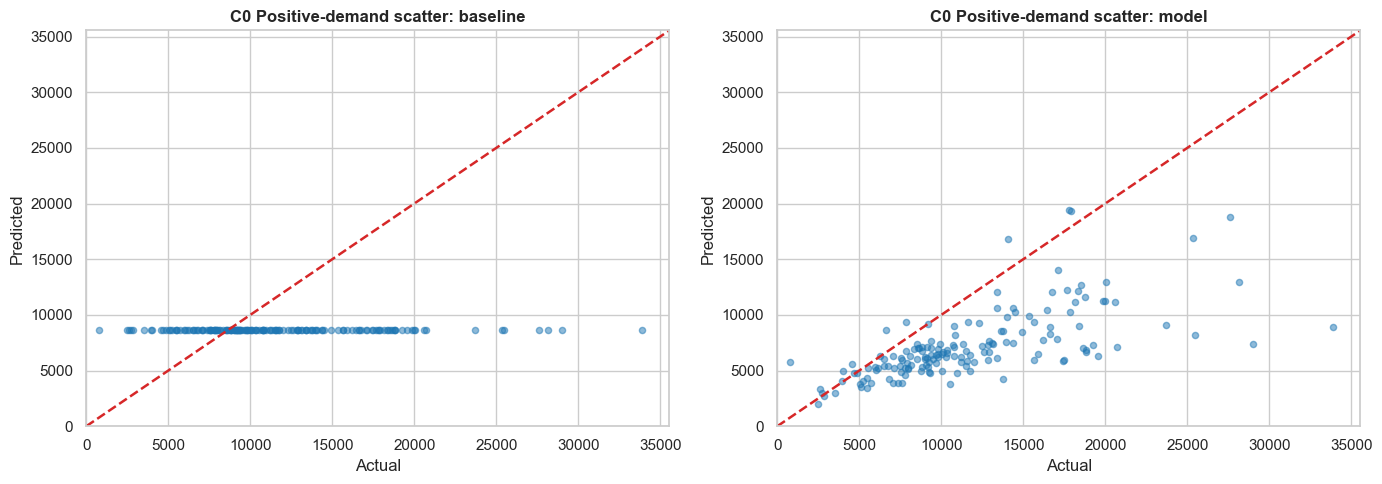

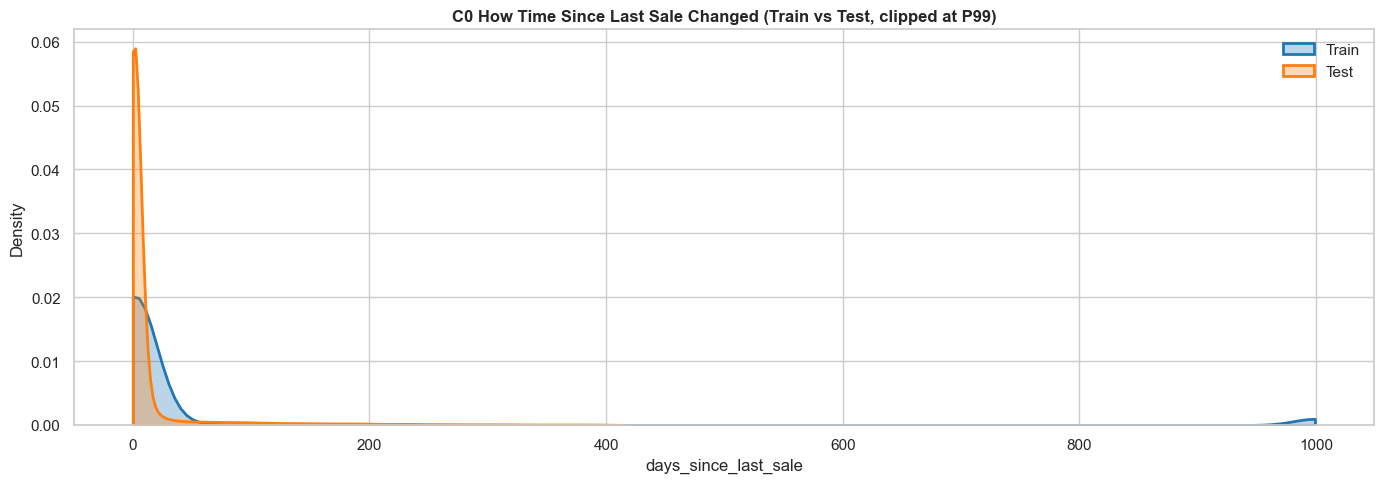

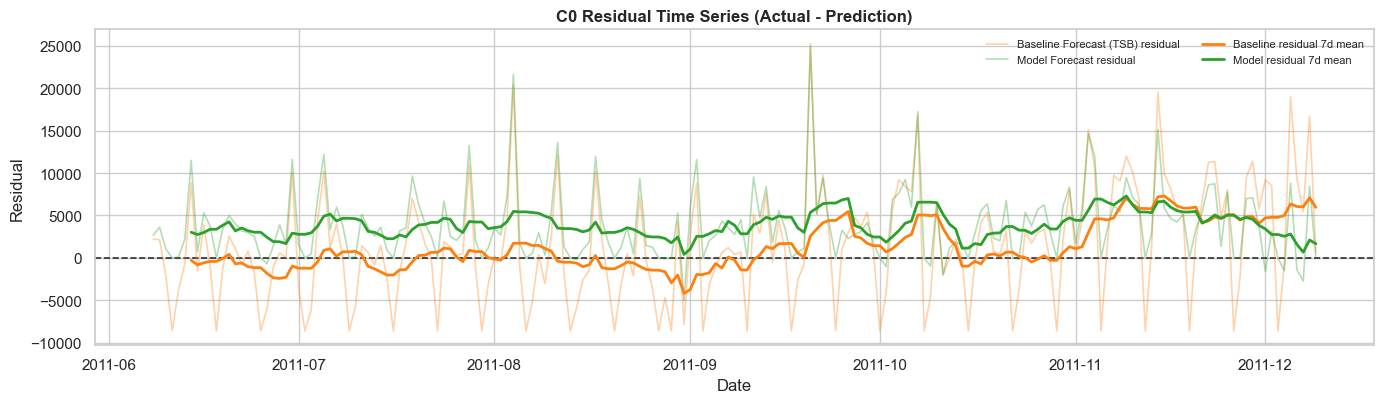

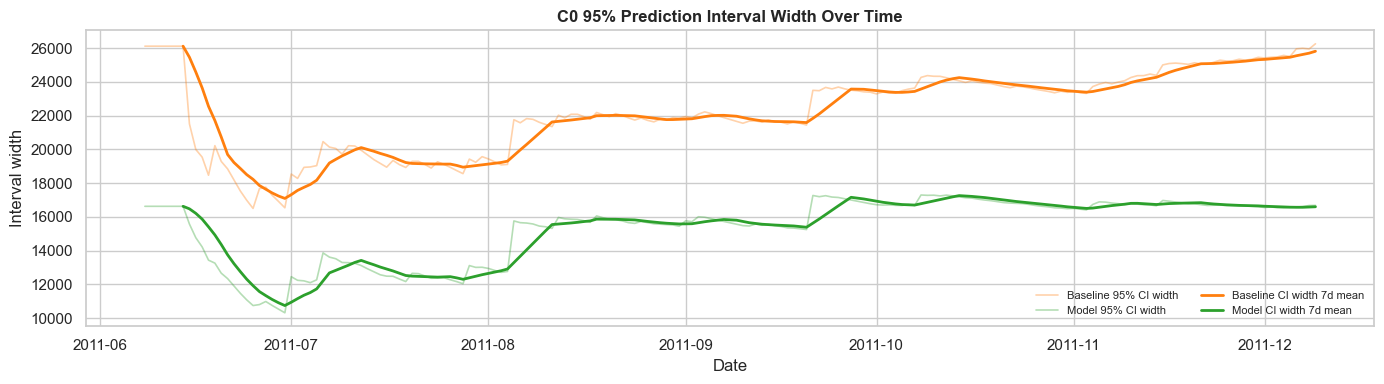

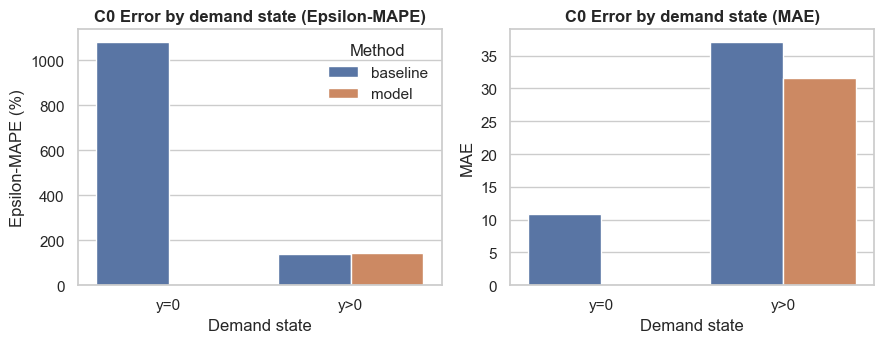

,method,wmape_pct,epsilon_mape_pct,cap_mape_0_100,tail_ape_p90,tail_ape_p95,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap,signed_pct_error_mean,signed_abs_bias_ratio
0,Model 2 (Two-stage LGBM),69.84841,62.948834,26.484377,138.090181,312.129628,0.432674,0.432055,0.000619,43.760733,-0.374442
1,Model 1 (TSB),113.36437,672.387858,67.456974,1524.180544,2547.707928,0.765049,0.432055,0.332994,636.175390,-0.136379


In [433]:
# Cluster 0 - Compare model 1 vs model 2
cluster0_compare_analysis = run_pair_analysis(
    actual_df=cluster0_model1_actual_df,
    baseline_df=cluster0_model1_pred_df,
    model_df=cluster0_model2_pred_df,
    train_feat=cluster0_model2_artifacts.train_feat,
    test_feat=cluster0_model2_artifacts.test_feat,
    cluster_id=cluster0_id,
    cluster_tag='c0',
    baseline_label=f'Model 1 ({C0_M1_DISPLAY_NAME})',
    model_label=f'Model 2 ({C0_M2_DISPLAY_NAME})',
    baseline_col=C0_M1_PRED_COL,
    model_col=C0_M2_PRED_COL,
    eps=cluster0_eps_mape,
    n_periods=cluster0_n_periods,
)
cluster0_metrics_compare = cluster0_compare_analysis['metric_table']

display(cluster0_metrics_compare)


In [434]:
# Cluster 0 - Full analysis tables
for key in ['confusion_by_period', 'error_decomposition']:
    display(cluster0_compare_analysis[key])


,method,period,TP,FP,FN,TN,TP_pct,FP_pct,FN_pct,TN_pct
0,baseline,P1,9094,9424,1059,4628,37.570750,38.934105,4.375129,19.120017
1,baseline,P2,8137,9987,787,4779,34.347826,42.157028,3.322077,20.173069
2,baseline,P3,8861,9263,1140,4426,37.403968,39.100886,4.812157,18.682989
3,baseline,P4,10508,7616,1578,3988,44.356268,32.148586,6.661038,16.834107
4,model,P1,10153,59,0,13993,41.945879,0.243751,0.000000,57.810370
5,model,P2,8924,0,0,14766,37.669903,0.000000,0.000000,62.330097
6,model,P3,10001,0,0,13689,42.216125,0.000000,0.000000,57.783875
7,model,P4,12086,0,0,11604,51.017307,0.000000,0.000000,48.982693


,method,state,count,epsilon_mape_pct,wmape_pct,mae
0,baseline,y=0,53654,1083.583966,5.813861e+07,10.835840
1,baseline,y>0,41164,138.435333,8.174966e+01,37.125654
2,model,y=0,53654,2.196067,1.178278e+05,0.021961
3,model,y>0,41164,141.752462,6.949377e+01,31.559784


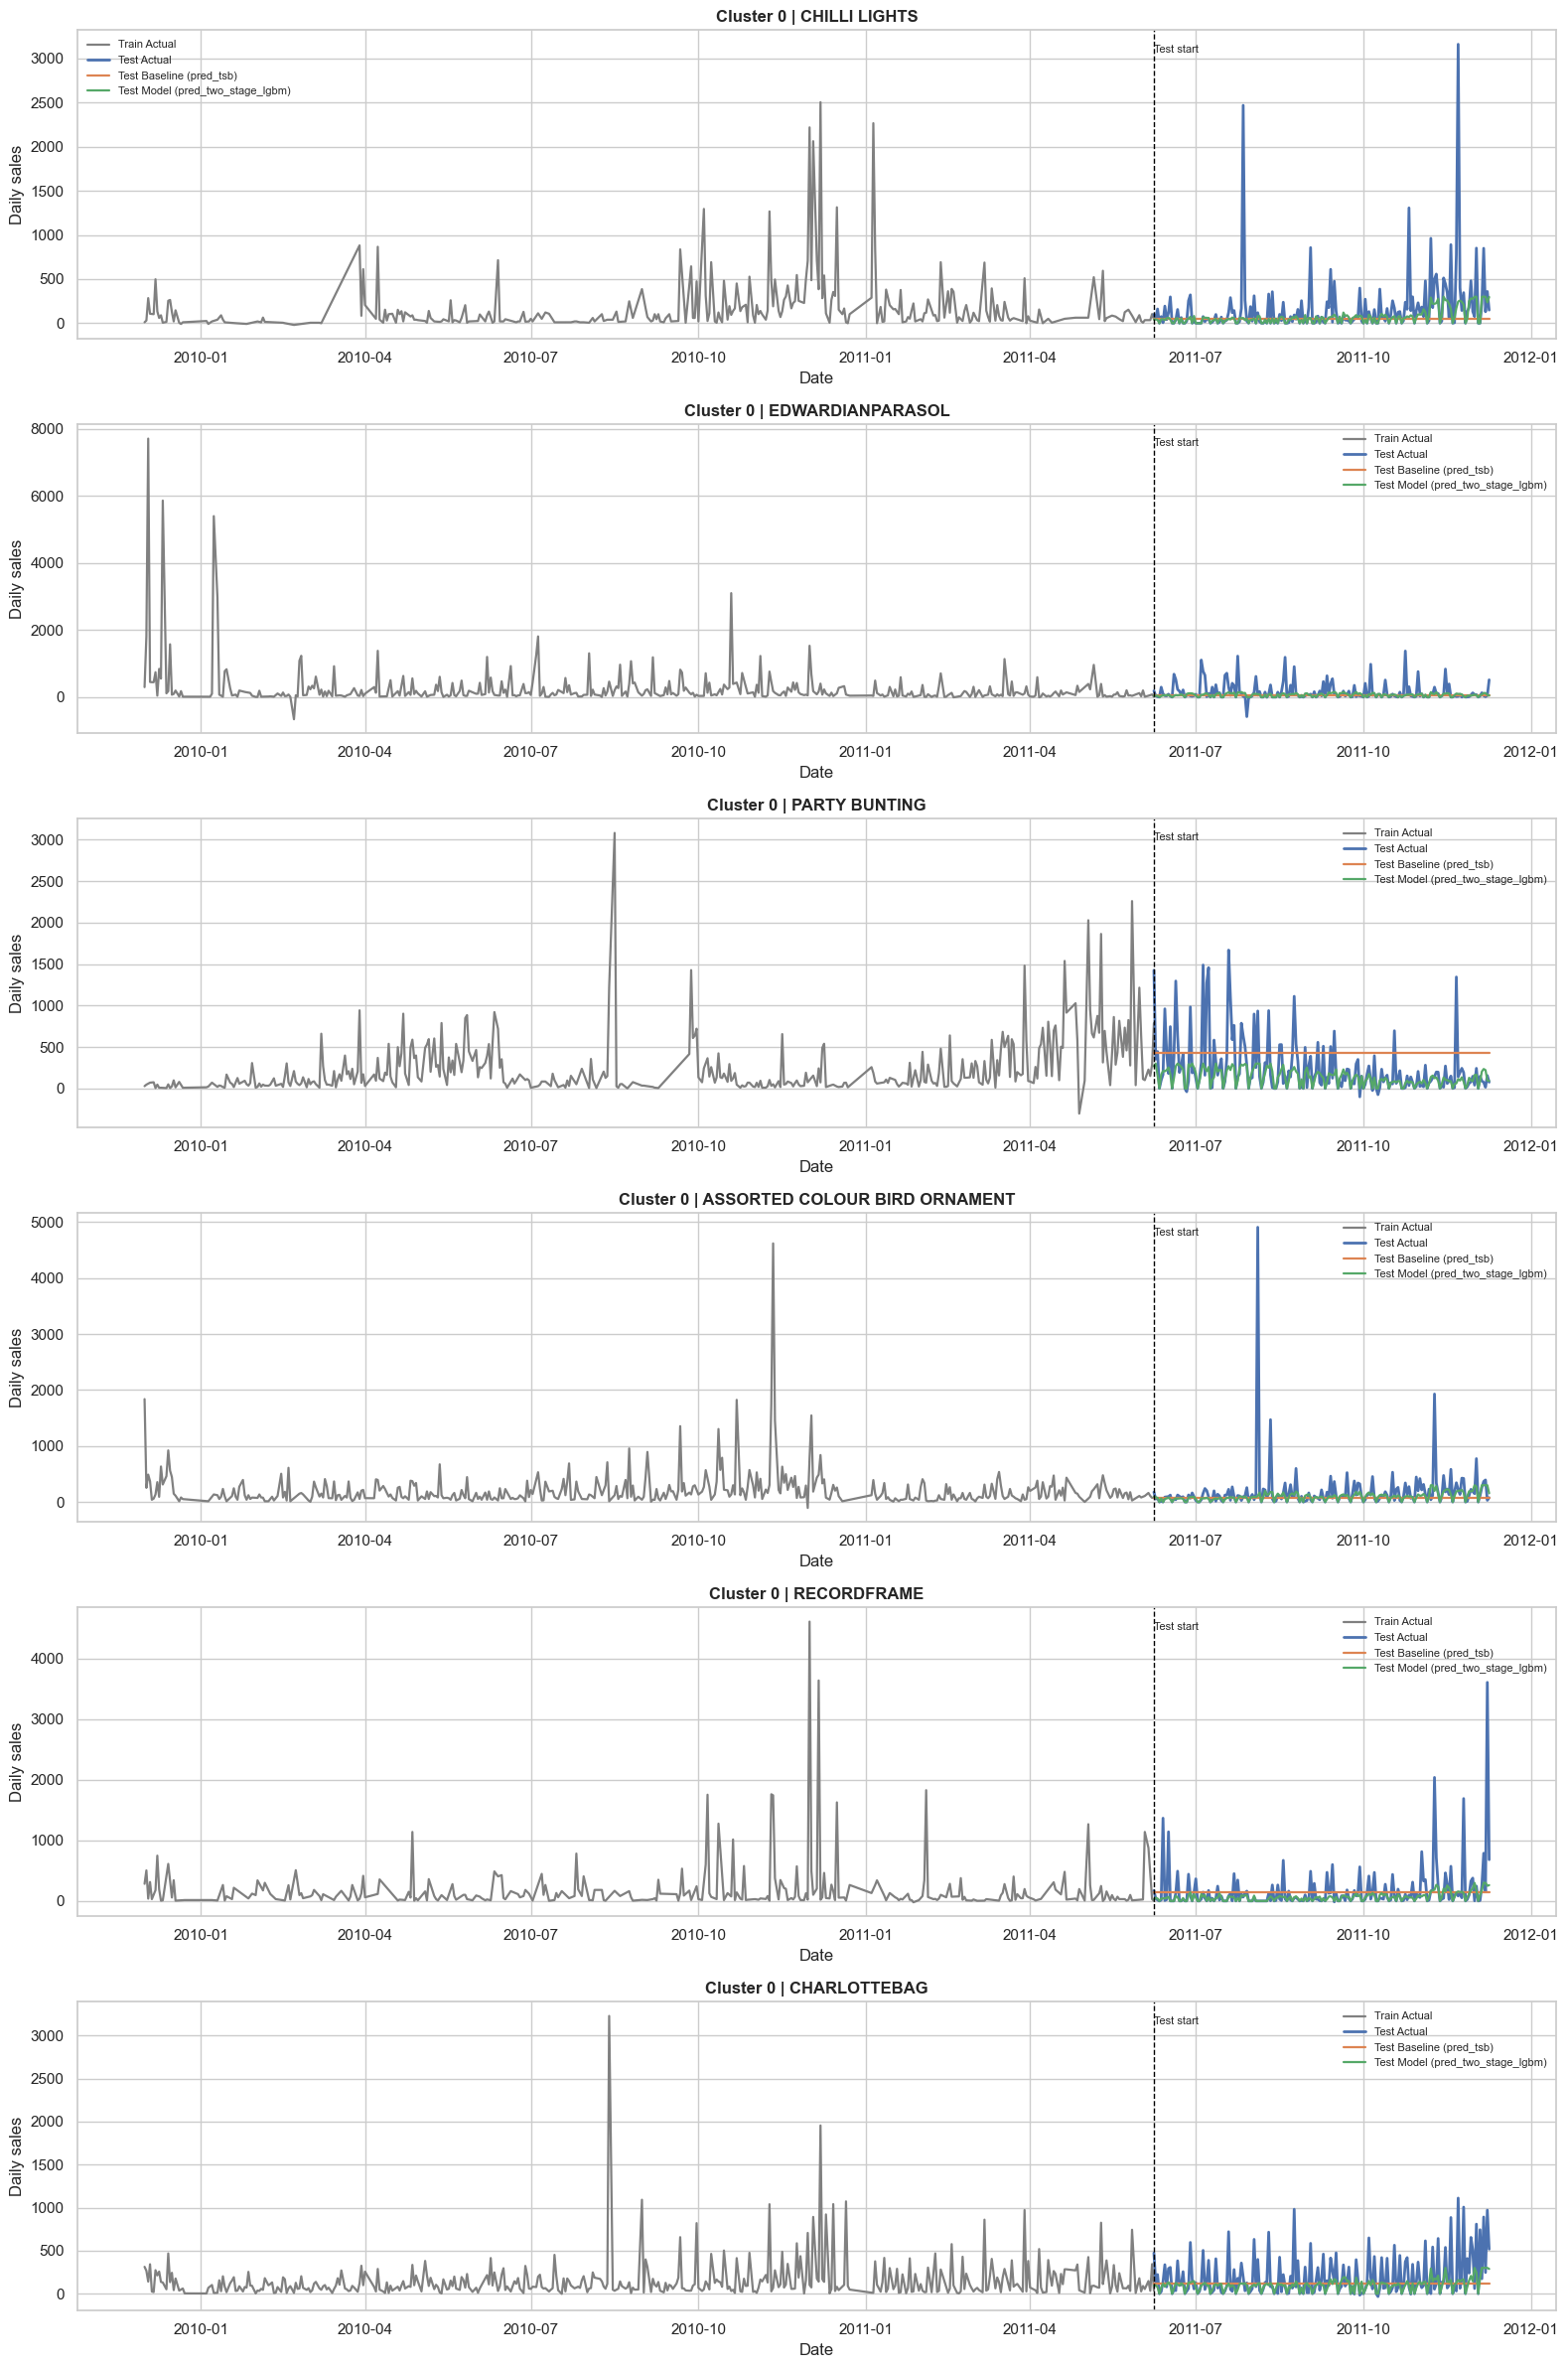

In [435]:
# Cluster 0 - Top-SKU plots
plot_top_sku_comparison(
    train_df=cluster0_train_df,
    actual_df=cluster0_model1_actual_df,
    baseline_df=cluster0_model1_pred_df,
    model_df=cluster0_model2_pred_df,
    top_n=cluster0_plot_top_n_skus,
    title_prefix='Cluster 0',
    baseline_col=C0_M1_PRED_COL,
    model_col=C0_M2_PRED_COL,
)


## Cluster 2

In [436]:
# Cluster 2 config
cluster2_id = 2
cluster2_eps_mape = 1.0
cluster2_metric_name = 'bounded_mape'
cluster2_n_periods = 4
cluster2_random_state = 42
cluster2_m1_random_search_mode = 'fast'
cluster2_m1_random_search_iter = 8
cluster2_m1_val_days = 28
cluster2_tune = True
cluster2_feature_cols = C2_DEFAULT_FEATURE_COLS.copy()
cluster2_categorical_feature_cols = C2_DEFAULT_CATEGORICAL_FEATURE_COLS.copy()
cluster2_prediction_output_path = 'forecasting/c2_m2_prediction.parquet'
cluster2_plot_top_n_skus = 6


In [437]:
# Cluster 2 shared data
cluster2_train_df, cluster2_test_df = c2_m1_load_data(cluster_id=cluster2_id)

print('cluster2 train shape:', cluster2_train_df.shape)
print('cluster2 test shape:', cluster2_test_df.shape)
print('cluster2 train sku:', cluster2_train_df['product_family_name'].nunique())
print('cluster2 test sku:', cluster2_test_df['product_family_name'].nunique())


cluster2 train shape: (4262, 4)
cluster2 test shape: (1527, 4)
cluster2 train sku: 10
cluster2 test sku: 10


In [438]:
# Cluster 2 helpers

def run_cluster2_model1():
    param_space = c2_m1_default_param_space(eps=cluster2_eps_mape, mode=cluster2_m1_random_search_mode)
    best_params, tuning_df = c2_m1_tune(
        train_df=cluster2_train_df,
        param_space=param_space,
        val_days=cluster2_m1_val_days,
        n_iter=cluster2_m1_random_search_iter,
        random_state=cluster2_random_state,
        verbose=True,
    )
    sku_actual_df, sku_pred_df, sku_model_info_df = c2_m1_forecast_panel(
        train_df=cluster2_train_df,
        test_df=cluster2_test_df,
        params=best_params,
    )
    return {
        'best_params': best_params,
        'tuning_df': tuning_df,
        'sku_actual_df': sku_actual_df,
        'sku_pred_df': sku_pred_df,
        'sku_model_info_df': sku_model_info_df,
    }


def eval_cluster2_model1(run_output):
    return evaluate_single_model(
        actual_df=run_output['sku_actual_df'],
        pred_df=run_output['sku_pred_df'],
        pred_col=C2_M1_PRED_COL,
        method_label=f'Cluster 2 / {C2_M1_DISPLAY_NAME}',
        eps=cluster2_eps_mape,
    )


def run_cluster2_model2():
    return run_c2_m2_pipeline(
        cluster_id=cluster2_id,
        feature_cols=cluster2_feature_cols,
        categorical_feature_cols=cluster2_categorical_feature_cols,
        tune=cluster2_tune,
        eps_mape=cluster2_eps_mape,
        random_state=cluster2_random_state,
        prediction_output_path=cluster2_prediction_output_path,
    )


def eval_cluster2_model2(artifacts):
    return evaluate_single_model(
        actual_df=artifacts.sku_actual_df,
        pred_df=artifacts.sku_pred_df,
        pred_col=C2_M2_PRED_COL,
        method_label=f'Cluster 2 / {C2_M2_DISPLAY_NAME}',
        eps=cluster2_eps_mape,
    )


In [439]:
# Cluster 2 - Model 1 (`c2_m1`) run
cluster2_model1_run = run_cluster2_model1()

print('Cluster 2 Model 1 best params:')
print(cluster2_model1_run['best_params'])
display(cluster2_model1_run['tuning_df'].head(20))
display(cluster2_model1_run['sku_model_info_df'].head(20))


[1/1] score=82.5329 cap_mape=61.2688 wmape=82.5329
Cluster 2 Model 1 best params:
{'seasonal_period': 7, 'min_train_len': 28, 'wmape_eps': 1.0, 'val_size': 14, 'selection_metric': '0.7*wmape + 0.3*zero_day_fpr', 'candidate_configs': [{'model_type': 'ets', 'trend': None, 'seasonal': 'add', 'seasonal_periods': 7, 'transform': 'log1p'}, {'model_type': 'ets', 'trend': None, 'seasonal': 'mul', 'seasonal_periods': 7, 'transform': 'log1p'}, {'model_type': 'ets', 'trend': 'add', 'seasonal': 'add', 'seasonal_periods': 7, 'damped_trend': False, 'transform': 'log1p'}, {'model_type': 'ets', 'trend': 'add', 'seasonal': 'add', 'seasonal_periods': 7, 'damped_trend': True, 'transform': 'log1p'}, {'model_type': 'ets', 'trend': 'add', 'seasonal': 'mul', 'seasonal_periods': 7, 'damped_trend': False, 'transform': 'log1p'}, {'model_type': 'ets', 'trend': 'add', 'seasonal': 'mul', 'seasonal_periods': 7, 'damped_trend': True, 'transform': 'log1p'}]}


,seasonal_period,min_train_len,wmape_eps,val_size,selection_metric,candidate_configs,search_score,metric_mape,metric_epsilon_mape,metric_cap_mape,metric_wmape,metric_zero_day_fpr
0,7,28,1.0,14,0.7*wmape + 0.3*zero_day_fpr,"[{'model_type': 'ets', 'trend': None, 'seasona...",82.532852,61.268814,307.816163,61.268814,82.532852,0.333333


,sku,model_type,candidate_name,trend,seasonal,seasonal_periods,damped_trend,transform,selection_score,train_sum,test_sum,pred_sum
0,CAKESTAND3TIER,ets,ets_tNone_sadd_p7_plain,None,add,7,None,log1p,53.535691,245095.00,57480.70,47918.354385
1,DOORMAT,ets,ets_tadd_sadd_p7_plain,add,add,7,False,log1p,60.097754,445513.09,173826.18,110387.726534
2,DOTCOM,ets,ets_tadd_sadd_p7_damped,add,add,7,True,log1p,45.362978,197138.45,125509.02,15418.218992
3,HANGINGHEARTT-LIGHTHOLDER,ets,ets_tadd_sadd_p7_plain,add,add,7,False,log1p,50.961716,214979.21,48365.47,27773.393676
4,HOTWATERBOTTLE,ets,ets_tNone_smul_p7_plain,None,mul,7,None,log1p,51.579794,212342.28,126370.52,1618.294557
5,JUMBOBAG,ets,ets_tadd_sadd_p7_damped,add,add,7,True,log1p,55.176547,434986.58,300816.48,178137.593612
6,LUNCHBAG,ets,ets_tadd_sadd_p7_damped,add,add,7,True,log1p,43.402831,198930.94,124851.77,79412.400236
7,METALSIGN,ets,ets_tadd_sadd_p7_plain,add,add,7,False,log1p,59.322469,233650.37,97408.24,23272.320294
8,PAPERCHAINKIT,ets,ets_tNone_sadd_p7_plain,None,add,7,None,log1p,50.121411,158867.45,85580.69,2903.141731
9,T-LIGHTHOLDER,ets,ets_tadd_sadd_p7_plain,add,add,7,False,log1p,42.404268,240561.90,81415.52,34079.351879


In [440]:
# Cluster 2 - Model 1 (`c2_m1`) eval
cluster2_model1_metric_table = eval_cluster2_model1(cluster2_model1_run)

display_metric_table(cluster2_model1_metric_table, title='Cluster 2 Model 1 evaluation')


Cluster 2 Model 1 evaluation


,method,wmape_pct,epsilon_mape_pct,cap_mape_0_100,tail_ape_p90,tail_ape_p95,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap,signed_pct_error_mean,signed_abs_bias_ratio
0,Cluster 2 / Holt-Winters / ETS,80.847463,2749.957456,73.728146,10134.930842,14017.136665,0.903784,0.821622,0.082162,2661.607561,-0.570607


In [441]:
# Cluster 2 - Model 2 (`c2_m2`) run
cluster2_model2_artifacts = run_cluster2_model2()
cluster2_model2_actual_df = cluster2_model2_artifacts.sku_actual_df
cluster2_model2_pred_df = cluster2_model2_artifacts.sku_pred_df

print('Cluster 2 Model 2 best config:')
print(cluster2_model2_artifacts.tuning_best_config)
print('prediction file:', cluster2_model2_artifacts.prediction_output_path)
display(cluster2_model2_artifacts.pred_df.head())
display(cluster2_model2_artifacts.tuning_trials.head(20) if cluster2_model2_artifacts.tuning_trials is not None else None)


Cluster 2 Model 2 best config:
{'reg_params': {'objective': 'poisson', 'n_estimators': 500, 'learning_rate': 0.03, 'num_leaves': 31, 'min_child_samples': 80, 'subsample': 1.0, 'colsample_bytree': 0.85, 'reg_alpha': 0.5, 'reg_lambda': 1.0, 'random_state': 42, 'verbose': -1}, 'cap_q': 0.99, 'threshold_mode': 'sku', 'tau_quantile': 0.05, 'recent_weight_max': 2.0, 'selection_metric': '0.6*WMAPE_0_100 + 0.2*POSITIVE_ONLY_MAPE_PCT + 0.2*ZERO_DAY_FPR', 'selection_score': 52.4593862642699}
prediction file: forecasting/c2_m2_prediction.parquet


,date,product_family_name,cluster,y,pred_global_lgbm_raw,pred_global_lgbm
555,2011-06-08,CAKESTAND3TIER,2,344.98,504.300470,504.300470
556,2011-06-09,CAKESTAND3TIER,2,512.87,532.507387,532.507387
557,2011-06-10,CAKESTAND3TIER,2,740.15,120.781074,120.781074
558,2011-06-11,CAKESTAND3TIER,2,0.00,0.477572,0.000000
559,2011-06-12,CAKESTAND3TIER,2,63.75,170.823976,170.823976


,score,metric_mape,metric_epsilon_mape,metric_wmape,metric_positive_only_mape,metric_zero_day_fpr,objective,n_estimators,learning_rate,num_leaves,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,tweedie_variance_power,threshold_mode,tau_quantile,cap_q,recent_weight_max,reg_params,tau
0,52.459386,38.954457,69.436906,57.040865,91.174336,0.0,poisson,500,0.03,31,80,1.00,0.85,0.5,1.0,1.3,sku,0.05,0.990,2.0,"{'objective': 'poisson', 'n_estimators': 500, ...",NaN
1,52.522580,40.322053,68.025655,57.765599,89.316105,0.0,poisson,500,0.05,31,80,0.85,0.85,0.1,0.0,1.5,sku,0.10,0.995,3.0,"{'objective': 'poisson', 'n_estimators': 500, ...",NaN
2,52.972114,39.241949,68.333759,58.379593,89.721794,0.0,tweedie,250,0.03,63,80,1.00,0.70,0.0,1.0,1.1,sku,0.05,0.999,1.5,"{'objective': 'tweedie', 'n_estimators': 250, ...",NaN
3,53.067068,42.686588,71.490830,57.152183,93.878792,0.0,poisson,350,0.05,31,20,0.85,1.00,0.0,1.0,1.5,global,0.10,0.990,3.0,"{'objective': 'poisson', 'n_estimators': 350, ...",63.745
4,53.407240,39.582040,70.482492,58.161705,92.551087,0.0,poisson,250,0.08,95,80,1.00,0.85,0.5,0.1,1.1,sku,0.05,0.990,1.5,"{'objective': 'poisson', 'n_estimators': 250, ...",NaN
5,53.670827,39.369232,70.892863,58.420900,93.091432,0.0,poisson,350,0.05,63,20,0.70,0.70,0.0,0.1,1.5,sku,0.05,0.999,2.0,"{'objective': 'poisson', 'n_estimators': 350, ...",NaN
6,53.683329,43.123082,71.908233,57.996083,94.428397,0.0,poisson,250,0.08,31,80,0.70,1.00,0.5,1.0,1.3,global,0.10,0.990,3.0,"{'objective': 'poisson', 'n_estimators': 250, ...",63.745
7,53.727124,40.391133,72.868339,57.647675,95.692594,0.0,poisson,350,0.03,95,40,1.00,1.00,0.5,1.0,1.1,global,0.05,0.995,1.0,"{'objective': 'poisson', 'n_estimators': 350, ...",29.450
8,53.860864,40.403479,68.782114,59.664056,90.312155,0.0,tweedie,250,0.05,31,80,0.85,0.70,0.0,0.1,1.5,sku,0.05,0.990,3.0,"{'objective': 'tweedie', 'n_estimators': 250, ...",NaN
9,53.952891,44.652969,73.377529,57.800465,96.363058,0.0,l1,350,0.03,63,40,1.00,1.00,0.1,0.1,1.3,global,0.20,0.990,1.0,"{'objective': 'l1', 'n_estimators': 350, 'lear...",142.240


In [442]:
# Cluster 2 - Model 2 (`c2_m2`) eval
cluster2_model2_metric_table = eval_cluster2_model2(cluster2_model2_artifacts)

display_metric_table(cluster2_model2_metric_table, title='Cluster 2 Model 2 evaluation')


Cluster 2 Model 2 evaluation


,method,wmape_pct,epsilon_mape_pct,cap_mape_0_100,tail_ape_p90,tail_ape_p95,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap,signed_pct_error_mean,signed_abs_bias_ratio
0,Cluster 2 / Global LGBM,57.019472,79.535581,43.447513,175.463712,296.07307,0.815676,0.821622,-0.005946,46.278788,-0.260417


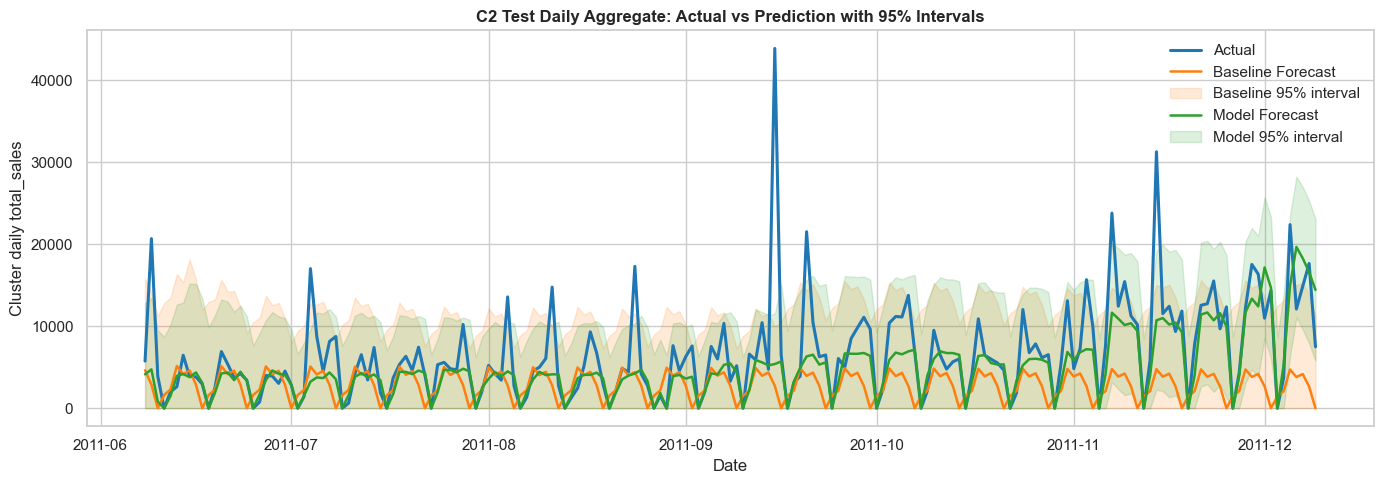

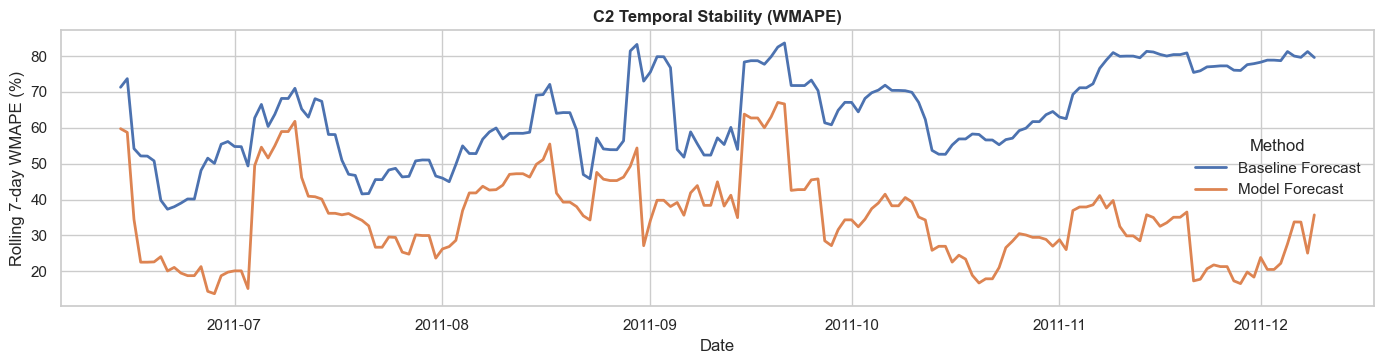

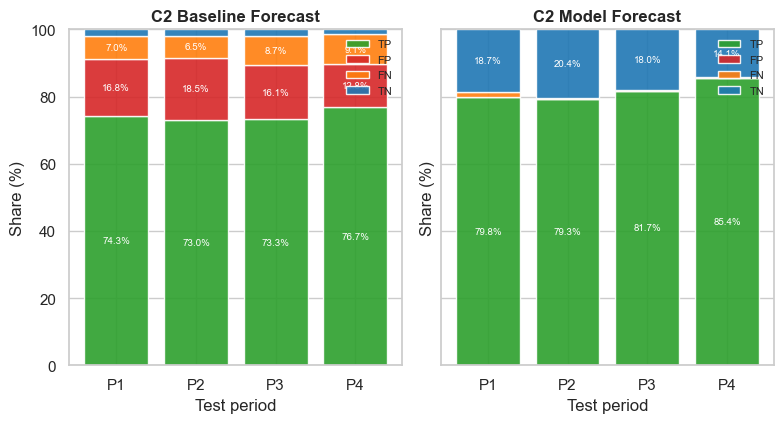

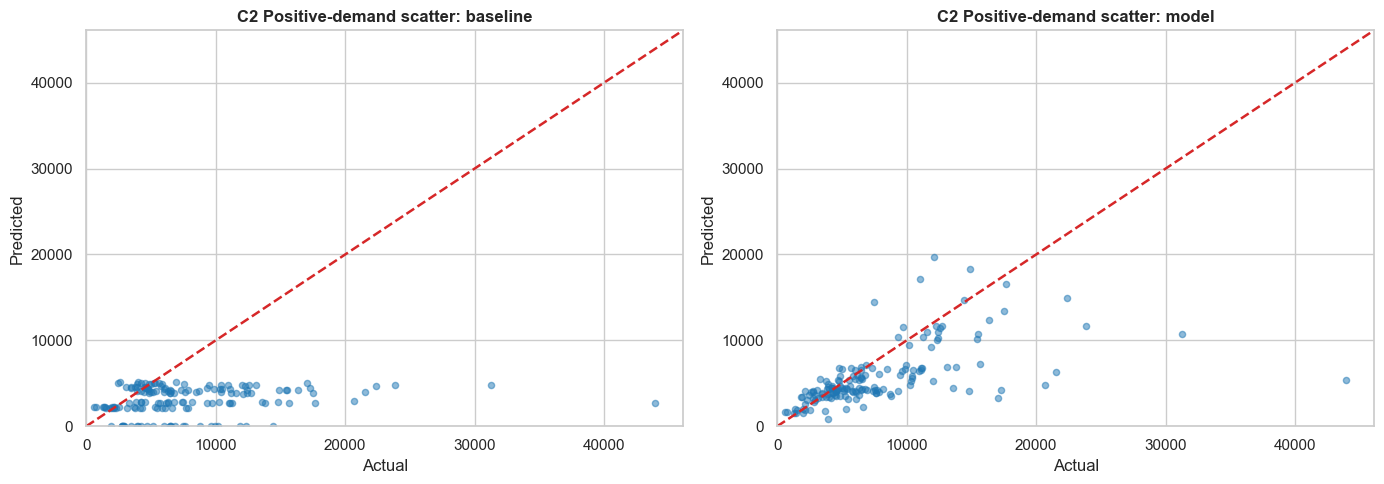

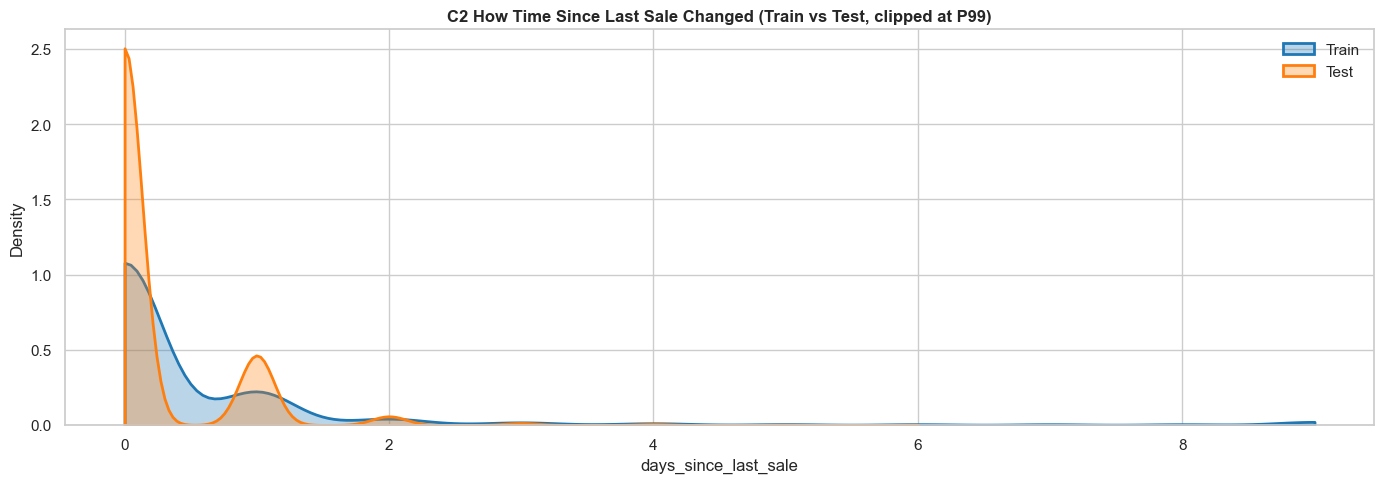

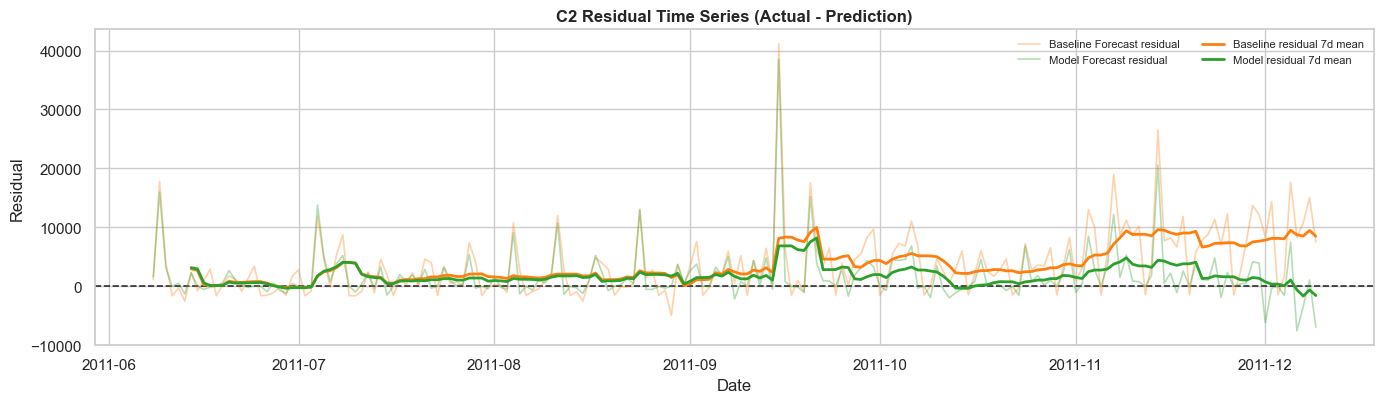

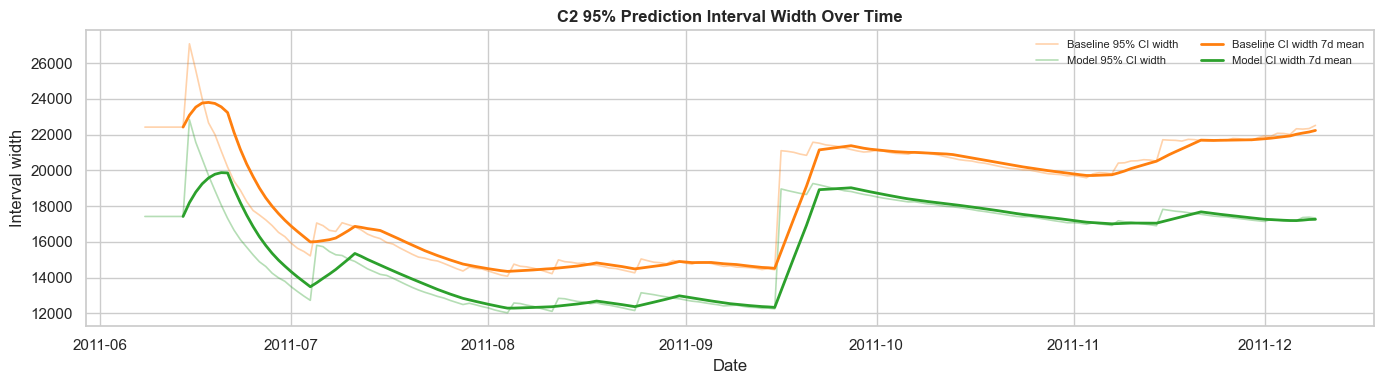

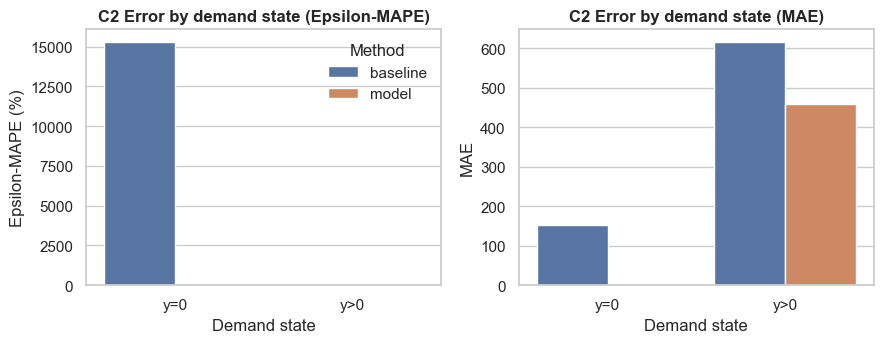

,method,wmape_pct,epsilon_mape_pct,cap_mape_0_100,tail_ape_p90,tail_ape_p95,pred_nonzero_rate,actual_nonzero_rate,nonzero_rate_gap,signed_pct_error_mean,signed_abs_bias_ratio
0,Model 2 (Global LGBM),57.019472,79.535581,43.447513,175.463712,296.073070,0.815676,0.821622,-0.005946,46.278788,-0.260417
1,Model 1 (Holt-Winters / ETS),80.847463,2749.957456,73.728146,10134.930842,14017.136665,0.903784,0.821622,0.082162,2661.607561,-0.570607


In [443]:
# Cluster 2 - Compare model 1 vs model 2
cluster2_compare_analysis = run_pair_analysis(
    actual_df=cluster2_model1_run['sku_actual_df'],
    baseline_df=cluster2_model1_run['sku_pred_df'],
    model_df=cluster2_model2_pred_df,
    train_feat=cluster2_model2_artifacts.train_feat,
    test_feat=cluster2_model2_artifacts.test_feat,
    cluster_id=cluster2_id,
    cluster_tag='c2',
    baseline_label=f'Model 1 ({C2_M1_DISPLAY_NAME})',
    model_label=f'Model 2 ({C2_M2_DISPLAY_NAME})',
    baseline_col=C2_M1_PRED_COL,
    model_col=C2_M2_PRED_COL,
    eps=cluster2_eps_mape,
    n_periods=cluster2_n_periods,
)
cluster2_metrics_compare = cluster2_compare_analysis['metric_table']

display(cluster2_metrics_compare)


In [444]:
# Cluster 2 - Full analysis tables
for key in ['confusion_by_period', 'error_decomposition']:
    display(cluster2_compare_analysis[key])


,method,period,TP,FP,FN,TN,TP_pct,FP_pct,FN_pct,TN_pct
0,baseline,P1,349,79,33,9,74.255319,16.808511,7.021277,1.914894
1,baseline,P2,336,85,30,9,73.043478,18.478261,6.521739,1.956522
2,baseline,P3,337,74,40,9,73.260870,16.086957,8.695652,1.956522
3,baseline,P4,353,59,42,6,76.739130,12.826087,9.130435,1.304348
4,model,P1,375,0,7,88,79.787234,0.000000,1.489362,18.723404
5,model,P2,365,0,1,94,79.347826,0.000000,0.217391,20.434783
6,model,P3,376,0,1,83,81.739130,0.000000,0.217391,18.043478
7,model,P4,393,0,2,65,85.434783,0.000000,0.434783,14.130435


,method,state,count,epsilon_mape_pct,wmape_pct,mae
0,baseline,y=0,323,15311.138204,4.945498e+06,153.111382
1,baseline,y>0,1520,92.408455,7.661809e+01,617.386146
2,model,y=0,323,0.000000,0.000000e+00,0.000000
3,model,y>0,1520,96.342648,5.690765e+01,458.560035


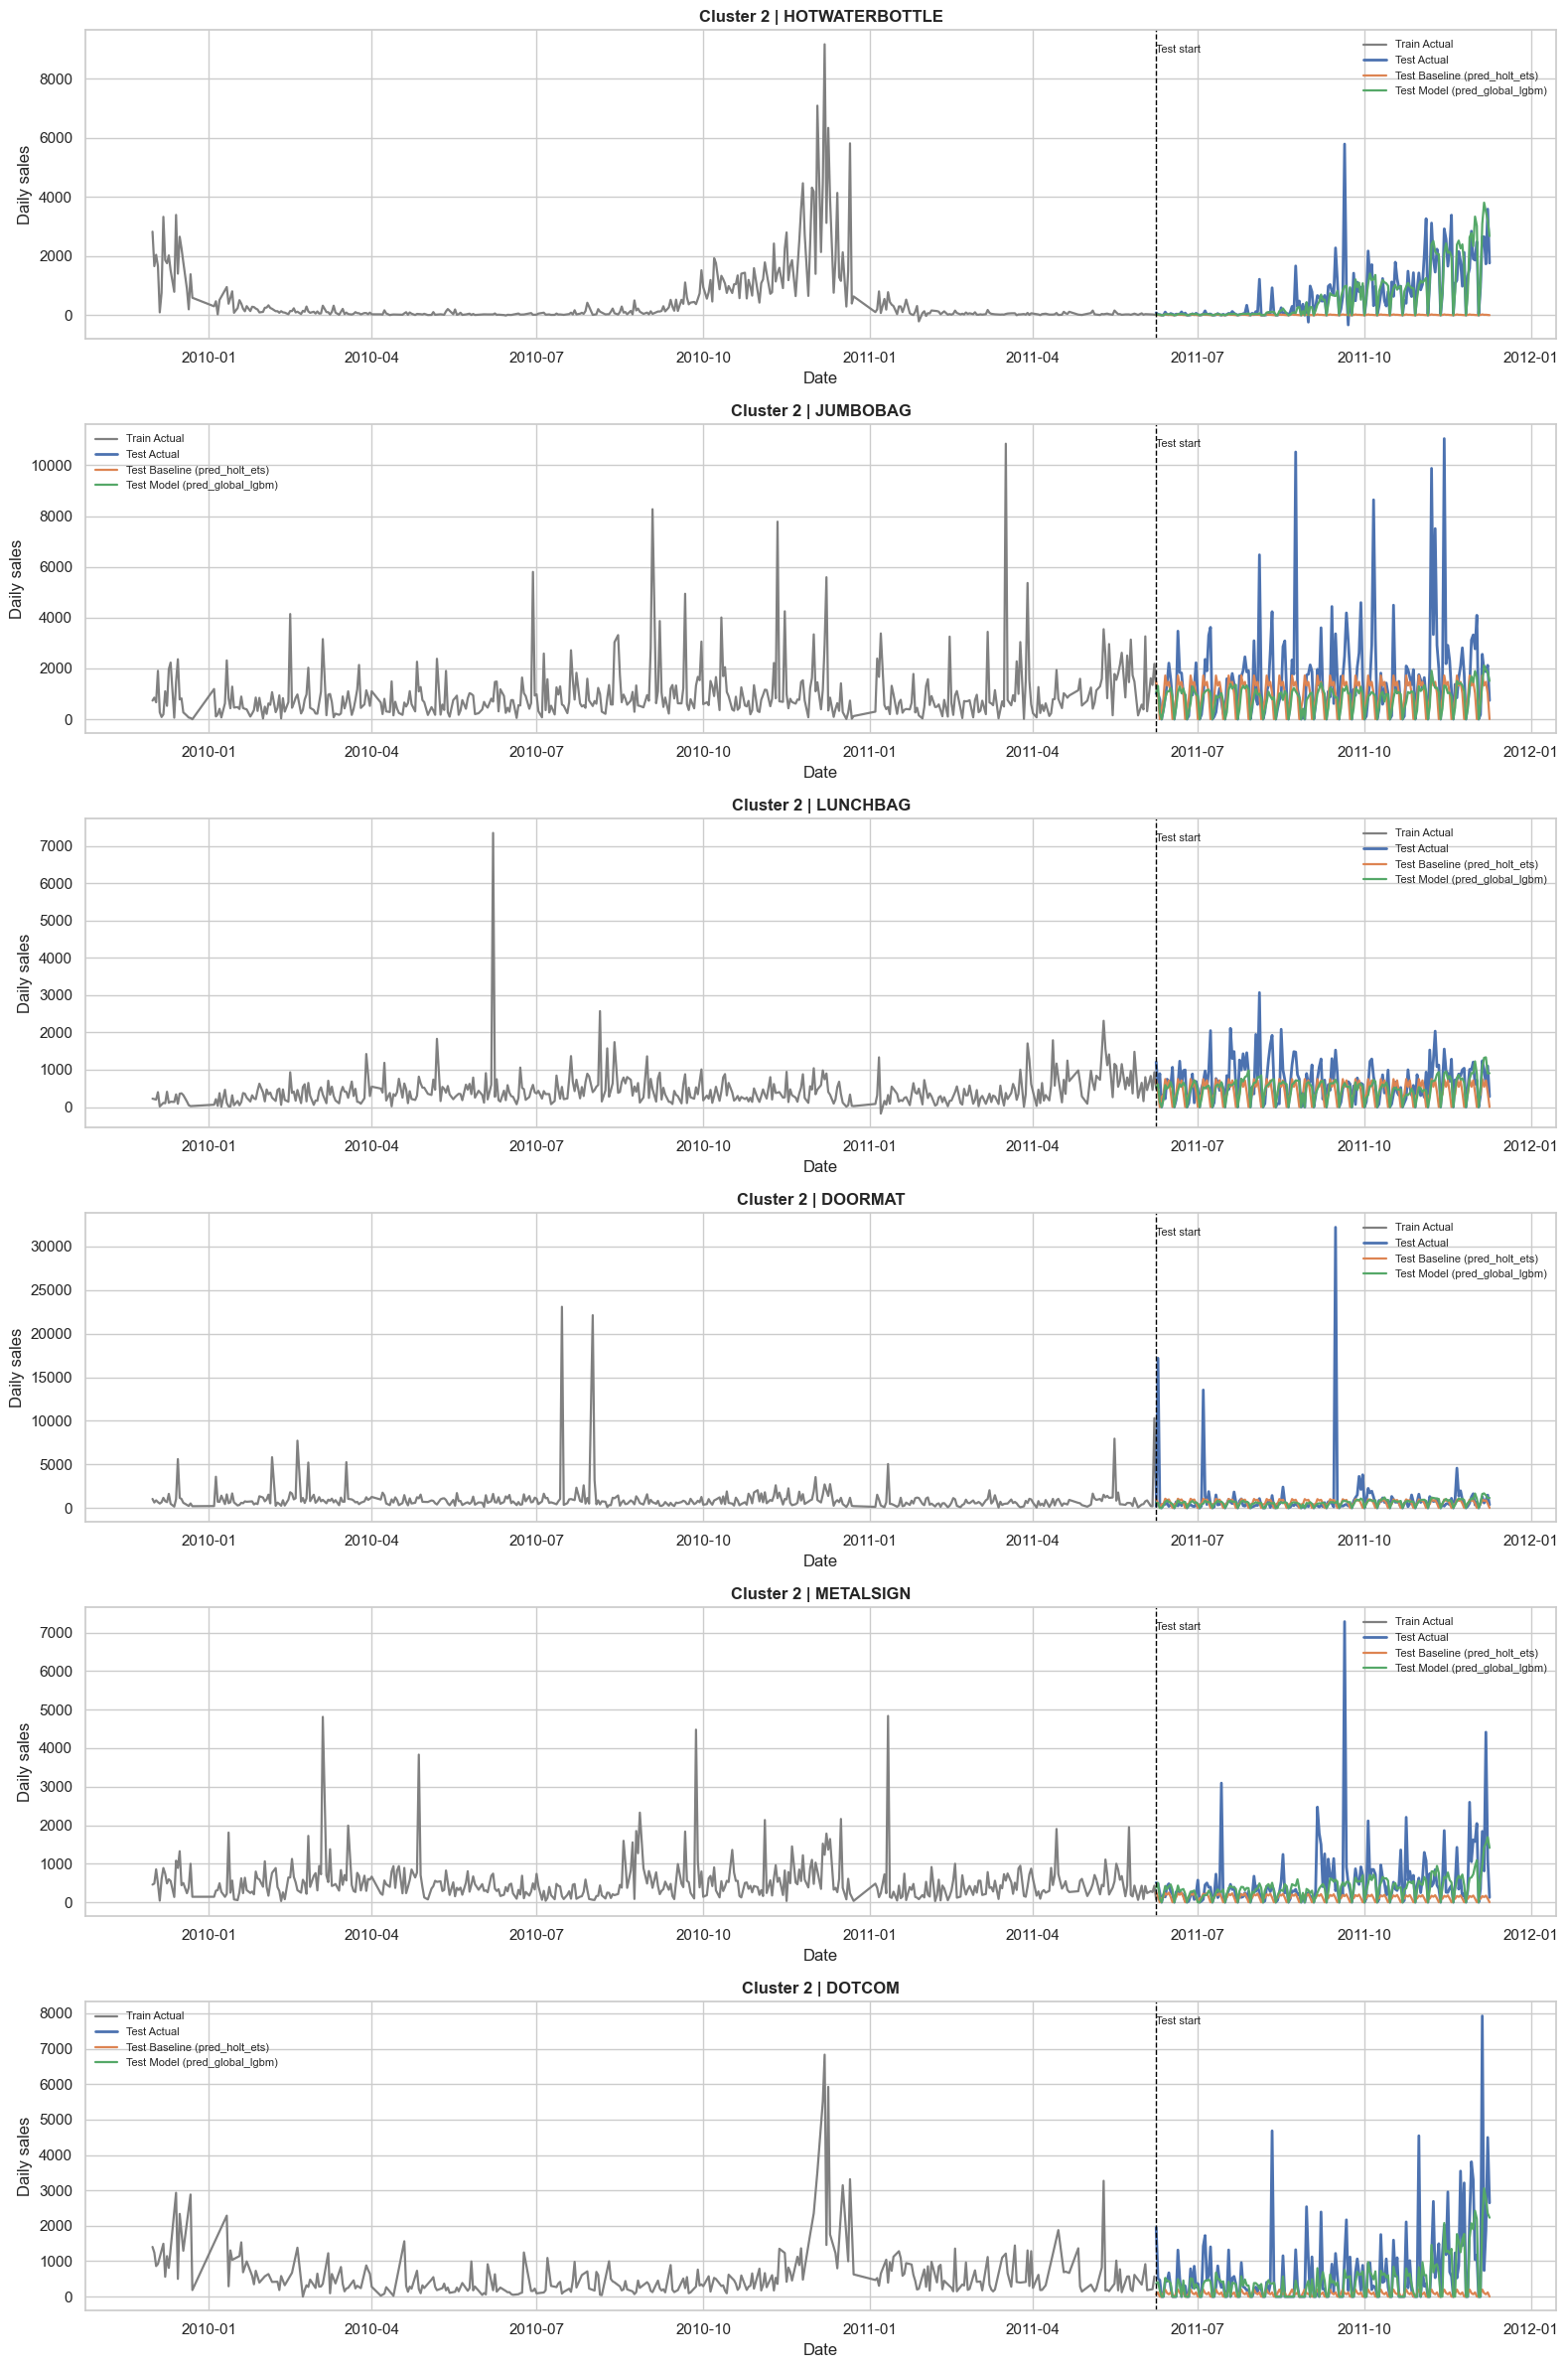

In [445]:
# Cluster 2 - Top-SKU plots
plot_top_sku_comparison(
    train_df=cluster2_train_df,
    actual_df=cluster2_model1_run['sku_actual_df'],
    baseline_df=cluster2_model1_run['sku_pred_df'],
    model_df=cluster2_model2_pred_df,
    top_n=cluster2_plot_top_n_skus,
    title_prefix='Cluster 2',
    baseline_col=C2_M1_PRED_COL,
    model_col=C2_M2_PRED_COL,
)
